# Surface Code Tutorial
### An Advanced Reference — Based on Craig Gidney's [Algorithmic Assertions](https://algassert.com/)

---

**Prerequisites:** Stabilizer formalism, Pauli group, syndrome measurement, Clifford circuits.

**Tools used:**
- [`stim`](https://github.com/quantumlib/stim) — fast stabilizer circuit simulator (Craig Gidney, 2021)
- [`pymatching`](https://github.com/oscartyrrell/PyMatching) — MWPM decoder
- [`sinter`](https://github.com/quantumlib/stim/tree/main/glue/sample) — threshold sampling
- [Crumble](https://algassert.com/crumble) — interactive 2D QEC circuit builder (browser)
- [Quirk](https://algassert.com/quirk) — drag-and-drop quantum circuit simulator (browser)

**Sections:**
1. Surface Code Fundamentals
2. Building Surface Code Circuits with Stim
3. Code Distance & Error Thresholds
4. Decoding with MWPM (PyMatching)
5. Lattice Surgery & Logical Gates
6. Tool Reference: Stim CLI, Crumble, Quirk

---

## 0. Installation

In [22]:
# Install required packages
# Run once; comment out after installation
!pip install stim pymatching sinter matplotlib numpy networkx

In [23]:
import stim
import pymatching
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import networkx as nx
from itertools import product

print(f"stim version      : {stim.__version__}")
print(f"pymatching version: {pymatching.__version__}")

stim version      : 1.15.0
pymatching version: 2.3.1


---
## 1. Surface Code Fundamentals

### 1.1 The Toric Code and the Planar Surface Code

The **toric code** [(Kitaev 1997)](https://arxiv.org/abs/quant-ph/9707021) is a CSS code defined on a 2D square lattice with periodic boundary conditions.  
The **planar (rotated) surface code** is the open-boundary variant used in practice — it avoids the need for a torus topology and was shown by Fowler et al. to be equivalent in threshold to the toric code.

We work exclusively with the **rotated surface code** (also called the *rotated planar code*), where the lattice is tilted 45° relative to the original Kitaev formulation.  This halves the qubit count for the same code distance.

### 1.2 Why the Rotated Planar Code?

There are many topological codes. The choice of the **rotated planar surface code**
as the leading candidate for fault-tolerant quantum computing is not arbitrary —
it results from optimizing across several competing constraints simultaneously.

#### Qubit efficiency: rotated vs. unrotated

The original (unrotated) surface code places data qubits on edges and ancillas on
faces/vertices of a square lattice. For code distance $d$ it requires $2d^2 + 2d - 1$
physical qubits. The **rotated** variant, obtained by tilting the lattice 45° and
reinterpreting the geometry, achieves the same distance $d$ with only $2d^2 - 1$
qubits — roughly a **2× reduction in qubit overhead** for the same level of protection.
This was shown by [Bombin & Martin-Delgado (2007)](https://arxiv.org/abs/quant-ph/0605138) and independently derived by
several groups. At $d = 17$ (a realistic fault-tolerant target), this saves 68 qubits
per logical qubit — significant at scale.

#### Why planar boundaries instead of toric?

The toric code requires a physical torus topology (periodic boundary conditions),
which is incompatible with 2D chip architectures. Planar boundaries replace this
with **smooth** (Z-type) and **rough** (X-type) boundaries:

| Boundary type | Terminates | Physical realization |
|---|---|---|
| Smooth (Z) | X-type strings (logical $\bar{X}$) | Left/right edges of the patch |
| Rough (X) | Z-type strings (logical $\bar{Z}$) | Top/bottom edges of the patch |

Planar boundaries cost no extra qubits, are compatible with nearest-neighbor 2D
connectivity, and allow **lattice surgery** (patching boundaries together to perform
logical gates) — which would be impossible on a torus.

#### Why not other codes?

| Code | Threshold | Qubits per logical | Locality | Practical issue |
|---|---|---|---|---|
| Rotated surface | ~1% | $2d^2 - 1$ | 2D, weight-4 | Best overall balance |
| Color code | ~0.1% | $\sim 3d^2$ | 2D, weight-6 | Lower threshold, heavier stabilizers |
| Concatenated codes | ~0.01% | Exponential in levels | Non-local | High overhead, hard to schedule |
| Bacon-Shor | ~0.1% | $d^2$ | 2D, weight-2 | Sub-threshold performance poor |
| LDPC (asymptotically) | ~1-3% | $O(1)$ per logical | Non-local | Requires long-range connectivity |

The surface code wins on **threshold** (~1% under circuit-level noise, the highest
among local 2D codes), **gate locality** (all stabilizers are weight-4 and
nearest-neighbor), and **decoder maturity** (MWPM is near-optimal and runs
in real time).

#### Why not just use more qubits with a lower-threshold code?

Below threshold, what matters is the **slope** of $\log p_L$ vs $\log p$ — i.e., how
quickly the logical error rate drops as you increase $d$. The surface code's
distance-$d$ logical error rate scales as $(p/p_{\text{th}})^{\lfloor(d+1)/2\rfloor}$,
which is aggressive. A code with a lower threshold $p_{\text{th}}$ requires operating
at a much smaller $p$ to get the same suppression — which may not be achievable with
current hardware. The surface code's ~1% threshold is routinely within reach of
superconducting and trapped-ion platforms today.

**In summary:** the rotated planar surface code is the right choice because it is
the most qubit-efficient local 2D code, has the highest known threshold for
circuit-level noise, is compatible with planar chip architectures, and has a
mature ecosystem of decoders and tools (Stim, PyMatching, Crumble).

### 1.3 Qubit Layout — Rotated Surface Code, Distance d

For code distance $d$:
- **Data qubits:** $d^2$ arranged in a $d \times d$ grid.
- **Measure-Z (plaquette) ancillas:** $\lfloor d^2/2 \rfloor$ — detect X errors.
- **Measure-X (vertex) ancillas:** $\lfloor d^2/2 \rfloor$ — detect Z errors.
- **Total qubits:** $2d^2 - 1$

The code encodes **1 logical qubit** with distance $d$, meaning it can correct up to $\lfloor (d-1)/2 \rfloor$ arbitrary single-qubit errors.

### 1.4 Stabilizer Generators

Each ancilla qubit corresponds to one stabilizer generator:

| Ancilla type | Pauli weight | Detects |
|---|---|---|
| Z-type plaquette | $Z^{\otimes 4}$ (bulk) or $Z^{\otimes 2}$ (boundary) | X (bit-flip) errors |
| X-type vertex | $X^{\otimes 4}$ (bulk) or $X^{\otimes 2}$ (boundary) | Z (phase-flip) errors |

The stabilizer group $\mathcal{S} = \langle g_1, \ldots, g_{d^2-1} \rangle$ commutes with itself since every X-plaquette and Z-vertex share an even number of data qubits (0 or 2).

### 1.5 Logical Operators

The logical operators of the rotated surface code are **string operators** that traverse the lattice from boundary to boundary:

| Operator | Path | Acts as |
|---|---|---|
| $\bar{X}$ | Row of $X$s: left boundary → right boundary | Logical X |
| $\bar{Z}$ | Column of $Z$s: top boundary → bottom boundary | Logical Z |

The **minimum weight** of either logical operator equals $d$ — this defines the code distance.

Any error chain of weight $< d$ that creates a matching syndrome can be corrected;  
an undetected logical error requires a chain of weight $\geq d$.

### 1.6 Visualization: d=3 Rotated Surface Code

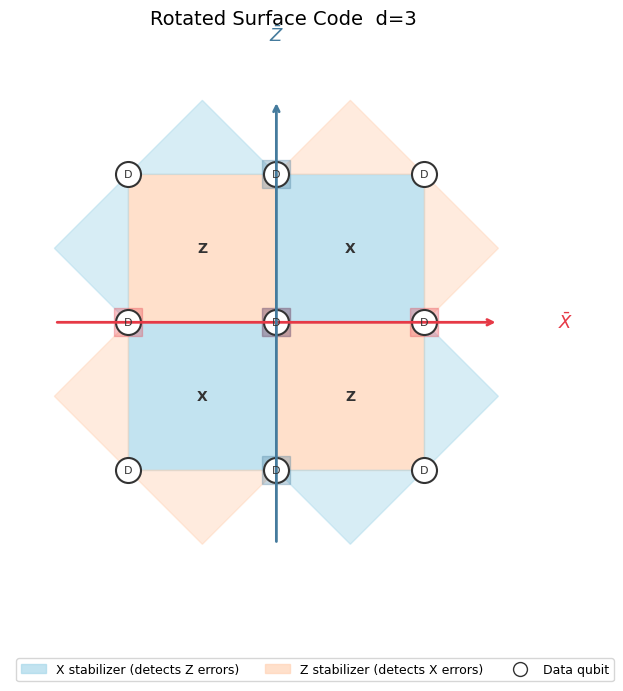

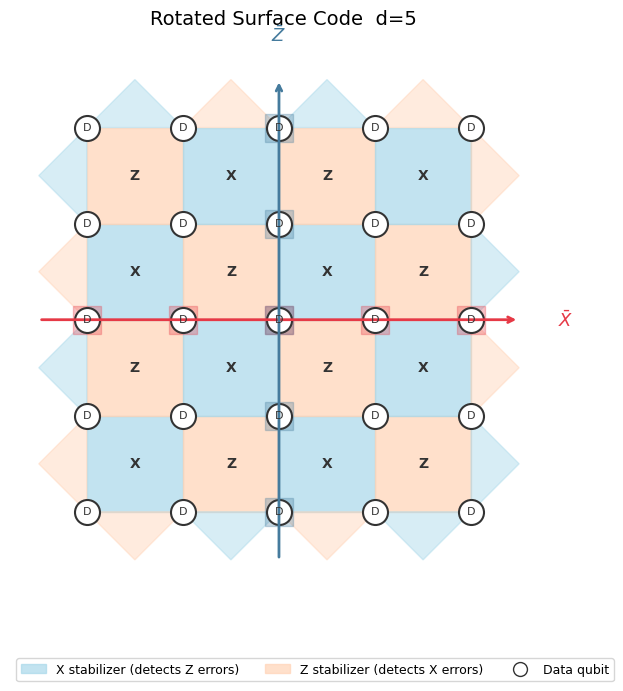

In [24]:
def plot_rotated_surface_code(d=3, show_logical=True):
    """
    Visualize the d x d rotated surface code.
    Data qubits on integer grid, ancillas at plaquette centers.
    """
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_aspect('equal')
    ax.set_title(f"Rotated Surface Code  d={d}", fontsize=14, pad=12)

    # ---- plaquettes / faces ------------------------------------------------
    # In the rotated code, we label cells on a (d-1)x(d-1) grid of squares
    # alternating X and Z type. Corner/edge half-plaquettes use 2-body stabilizers.
    colors = {"X": "#a8d8ea", "Z": "#ffd3b6"}

    for row in range(d - 1):
        for col in range(d - 1):
            ptype = "X" if (row + col) % 2 == 0 else "Z"
            square = plt.Polygon(
                [(col, row), (col + 1, row), (col + 1, row + 1), (col, row + 1)],
                closed=True, color=colors[ptype], alpha=0.7, zorder=0
            )
            ax.add_patch(square)
            ax.text(col + 0.5, row + 0.5, ptype,
                    ha='center', va='center', fontsize=10, fontweight='bold',
                    color='#333333')

    # ---- boundary half-plaquettes (top/bottom for X, left/right for Z) -----
    half_alpha = 0.45
    # Top row: X half-plaquettes for even cols
    for col in range(d - 1):
        ptype = "X" if (0 + col) % 2 == 0 else "Z"
        boundary_color = colors[ptype]
        tri = plt.Polygon(
            [(col, d - 1), (col + 1, d - 1), (col + 0.5, d - 0.5)],
            closed=True, color=boundary_color, alpha=half_alpha, zorder=0
        )
        ax.add_patch(tri)
    for col in range(d - 1):
        ptype = "X" if col % 2 == 1 else "Z"
        boundary_color = colors[ptype]
        tri = plt.Polygon(
            [(col, 0), (col + 1, 0), (col + 0.5, -0.5)],
            closed=True, color=boundary_color, alpha=half_alpha, zorder=0
        )
        ax.add_patch(tri)
    for row in range(d - 1):
        ptype = "Z" if row % 2 == 0 else "X"
        boundary_color = colors[ptype]
        tri = plt.Polygon(
            [(0, row), (0, row + 1), (-0.5, row + 0.5)],
            closed=True, color=boundary_color, alpha=half_alpha, zorder=0
        )
        ax.add_patch(tri)
    for row in range(d - 1):
        ptype = "Z" if row % 2 == 1 else "X"
        boundary_color = colors[ptype]
        tri = plt.Polygon(
            [(d - 1, row), (d - 1, row + 1), (d - 0.5, row + 0.5)],
            closed=True, color=boundary_color, alpha=half_alpha, zorder=0
        )
        ax.add_patch(tri)

    # ---- data qubits -------------------------------------------------------
    for row in range(d):
        for col in range(d):
            ax.plot(col, row, 'o', markersize=18, color='white',
                    markeredgecolor='#333333', markeredgewidth=1.5, zorder=3)
            ax.text(col, row, f"D", ha='center', va='center',
                    fontsize=8, color='#333333', zorder=4)

    # ---- logical operators -------------------------------------------------
    if show_logical:
        # Logical X: horizontal string through middle row
        mid = d // 2
        for col in range(d):
            ax.plot(col, mid, 's', markersize=20, color='#e63946',
                    alpha=0.3, zorder=2)
        ax.annotate('', xy=(d - 0.5, mid), xytext=(-0.5, mid),
                    arrowprops=dict(arrowstyle='->', color='#e63946', lw=2))
        ax.text(d - 0.1, mid, r'$\bar{X}$', color='#e63946',
                fontsize=13, va='center')

        # Logical Z: vertical string through middle col
        for row in range(d):
            ax.plot(mid, row, 's', markersize=20, color='#457b9d',
                    alpha=0.3, zorder=2)
        ax.annotate('', xy=(mid, d - 0.5), xytext=(mid, -0.5),
                    arrowprops=dict(arrowstyle='->', color='#457b9d', lw=2))
        ax.text(mid, d - 0.1, r'$\bar{Z}$', color='#457b9d',
                fontsize=13, ha='center')

    # ---- legend ------------------------------------------------------------
    legend_elements = [
        mpatches.Patch(color=colors["X"], alpha=0.7, label="X stabilizer (detects Z errors)"),
        mpatches.Patch(color=colors["Z"], alpha=0.7, label="Z stabilizer (detects X errors)"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
                   markeredgecolor='#333333', markersize=10, label='Data qubit'),
    ]
    ax.legend(handles=legend_elements, loc='lower left',
              bbox_to_anchor=(0, -0.18), ncol=3, fontsize=9)

    ax.set_xlim(-0.8, d - 0.1)
    ax.set_ylim(-0.8, d - 0.1)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_rotated_surface_code(d=3)
plot_rotated_surface_code(d=5)

**Reading the d=3 plot:**
- The 9 white circles are **data qubits** — these carry the logical information.
- Blue tiles are **X-type stabilizers**: each bulk tile measures $X \otimes X \otimes X \otimes X$
  on its 4 corner data qubits; edge half-tiles measure weight-2 versions.
- Orange tiles are **Z-type stabilizers**: same geometry but with $Z \otimes Z \otimes Z \otimes Z$.
- The red arrow ($\bar{X}$) shows the minimum-weight logical X operator — a horizontal
  string of 3 X gates crossing the patch left-to-right. Any X error chain that
  mimics this string causes an undetectable logical flip.
- The blue arrow ($\bar{Z}$) shows the minimum-weight logical Z operator — a vertical
  string of 3 Z gates crossing top-to-bottom.
- Both strings have weight $d = 3$, confirming the code distance.

**Reading the d=5 plot:**
- Now 25 data qubits and 24 ancillas ($2 \times 25 - 1 = 49$ total).
- The logical strings now have weight 5 — an adversary needs to place at least
  5 coordinated errors to cause a logical failure, compared to 3 for d=3.
- Notice how the bulk stabilizers are all weight-4 (touching 4 data qubits),
  while boundary stabilizers remain weight-2. This is the key locality property
  that makes the surface code implementable on a 2D nearest-neighbor chip.
- The number of stabilizer generators is $d^2 - 1 = 24$, leaving exactly
  1 logical qubit encoded in the $2^{25}$-dimensional Hilbert space.

---
## 2. Building Surface Code Circuits with Stim

**Stim** represents stabilizer circuits as sequences of Clifford gates plus error mechanisms.  
It natively understands QEC concepts: `DETECTOR`, `OBSERVABLE_INCLUDE`, `TICK`, and various noise channels.

### 2.1 Generating the Standard Rotated Surface Code Circuit

Stim ships with a built-in circuit generator for common QEC codes via `stim.Circuit.generated()`.  
The `surface_code:rotated_memory_z` task runs a logical Z memory experiment:
- Prepare in $|\bar{0}\rangle$ (eigenstate of $\bar{Z}$)
- Run $d$ rounds of syndrome extraction
- Measure out; decode to check for logical errors

**Key parameters:**

| Parameter | Meaning |
|---|---|
| `rounds` | Number of QEC cycles |
| `distance` | Code distance $d$ |
| `after_clifford_depolarization` | Depolarizing noise $p$ after each gate |
| `before_round_data_depolarization` | Idle noise on data qubits |
| `after_reset_flip_probability` | Reset error probability |
| `before_measure_flip_probability` | Measurement flip probability |

In [25]:
# Generate a d=3 surface code circuit with a simple depolarizing noise model
d = 3
p = 1e-3  # physical error rate

circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=d,           # typically use d rounds (one full QEC cycle per distance unit)
    distance=d,
    after_clifford_depolarization=p,
    before_round_data_depolarization=p,
    after_reset_flip_probability=p,
    before_measure_flip_probability=p,
)

print(f"Circuit stats for d={d}, p={p}:")
print(f"  Num qubits           : {circuit.num_qubits}")
print(f"  Num measurements     : {circuit.num_measurements}")
print(f"  Num detectors        : {circuit.num_detectors}")
print(f"  Num observables      : {circuit.num_observables}")
print()
# Print first 50 lines of the circuit
circuit_str = str(circuit)
lines = circuit_str.split('\n')
print('\n'.join(lines[:60]))
print('... (truncated)')

Circuit stats for d=3, p=0.001:
  Num qubits           : 26
  Num measurements     : 33
  Num detectors        : 24
  Num observables      : 1

QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 1) 3
QUBIT_COORDS(5, 1) 5
QUBIT_COORDS(1, 3) 8
QUBIT_COORDS(2, 2) 9
QUBIT_COORDS(3, 3) 10
QUBIT_COORDS(4, 2) 11
QUBIT_COORDS(5, 3) 12
QUBIT_COORDS(6, 2) 13
QUBIT_COORDS(0, 4) 14
QUBIT_COORDS(1, 5) 15
QUBIT_COORDS(2, 4) 16
QUBIT_COORDS(3, 5) 17
QUBIT_COORDS(4, 4) 18
QUBIT_COORDS(5, 5) 19
QUBIT_COORDS(4, 6) 25
R 1 3 5 8 10 12 15 17 19
X_ERROR(0.001) 1 3 5 8 10 12 15 17 19
R 2 9 11 13 14 16 18 25
X_ERROR(0.001) 2 9 11 13 14 16 18 25
TICK
DEPOLARIZE1(0.001) 1 3 5 8 10 12 15 17 19
H 2 11 16 25
DEPOLARIZE1(0.001) 2 11 16 25
TICK
CX 2 3 16 17 11 12 15 14 10 9 19 18
DEPOLARIZE2(0.001) 2 3 16 17 11 12 15 14 10 9 19 18
TICK
CX 2 1 16 15 11 10 8 14 3 9 12 18
DEPOLARIZE2(0.001) 2 1 16 15 11 10 8 14 3 9 12 18
TICK
CX 16 10 11 5 25 19 8 9 17 18 12 13
DEPOLARIZE2(0.001) 16 10 11 5 25 19 8 9 17 18 12 13

**Reading the circuit stats:**
- **17 qubits** = $2d^2 - 1 = 2(9) - 1$, confirming the rotated code layout.
- **Measurements** include both ancilla mid-circuit measurements (syndrome extraction)
  and final data qubit measurements. With $d=3$ rounds, each of the 8 ancillas is
  measured 3 times, plus 9 final data measurements = $8 \times 3 + 9 = 33$.
- **Detectors** are XOR combinations of measurements that should always be 0 in a
  noiseless circuit. A fired detector (value 1) signals that an error occurred nearby.
  The number of detectors is less than the number of measurements because final data
  measurements are combined with ancilla history.
- **1 observable** = the single logical qubit. Its value is computed from a subset
  of final data measurements that implement $\bar{Z}$.

The printed circuit text shows the actual Stim instruction sequence — scan for
`DEPOLARIZE2` instructions after each `CX` gate to see where two-qubit noise is injected,
and `DETECTOR` declarations at the end of each round.

### 2.2 Anatomy of a Stim Circuit

Key Stim instructions you'll encounter:

| Instruction | Meaning |
|---|---|
| `QUBIT_COORDS(x, y) q` | Attach 2D coordinates to qubit `q` (used by decoders/visualizers) |
| `RESET q` | Reset qubit to $|0\rangle$ |
| `H q` | Hadamard gate |
| `CNOT c t` | Controlled-NOT |
| `DEPOLARIZE1(p) q` | Single-qubit depolarizing channel: applies $X$, $Y$, or $Z$ each with probability $p/3$ |
| `DEPOLARIZE2(p) a b` | Two-qubit depolarizing channel (15 non-identity Paulis) |
| `X_ERROR(p) q` | Bit-flip error with probability $p$ |
| `M q` | Measure in Z basis |
| `TICK` | Separates time layers (one gate cycle) |
| `DETECTOR(x, y, t) rec[-k]` | Declares a detector: XOR of listed measurement records should be 0 |
| `OBSERVABLE_INCLUDE(0) rec[-k]` | Marks measurements that contribute to observable 0 |

**Detectors** are the core abstraction: each detector computes an XOR of measurement outcomes. In a noiseless circuit, every detector fires as 0. A detector flipping to 1 signals an error.

### 2.3 Sampling Syndromes

In [26]:
# Compile and sample the circuit
sampler = circuit.compile_detector_sampler()

# Sample 10 shots: returns (num_shots x num_detectors) bool array
detection_events, observable_flips = sampler.sample(
    shots=10,
    separate_observables=True
)

print(f"detection_events shape : {detection_events.shape}")
print(f"observable_flips shape : {observable_flips.shape}")
print()
print("First 5 shots — detection events (1 = detector fired):")
print(detection_events[:5].astype(int))
print()
print("First 5 shots — logical observable flip (1 = logical error):")
print(observable_flips[:5].astype(int))

detection_events shape : (10, 24)
observable_flips shape : (10, 1)

First 5 shots — detection events (1 = detector fired):
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

First 5 shots — logical observable flip (1 = logical error):
[[0]
 [0]
 [0]
 [0]
 [0]]


**Reading the sample output:**
- Each row is one **shot** (one full run of the circuit from reset to final measurement).
- Each column is one **detector**. A `1` means that detector fired — the corresponding
  stabilizer measurement disagreed with its reference, indicating a nearby error.
- Most entries are `0` (no error detected) since $p = 10^{-3}$ is well below threshold
  and errors are rare per gate.
- The `observable_flips` column tells you whether the logical qubit was correctly
  preserved: `0` = success, `1` = logical error occurred and was not corrected.
  At this error rate you expect very few `1`s.
- **Detectors and observables are independent:** a shot can have many fired detectors
  (lots of errors detected and corrected) and still have `observable_flip = 0` if
  the decoder correctly identifies the error chain.

In [27]:
# Build the Detector Error Model (DEM) — used directly by decoders
# The DEM describes which error mechanisms cause which detectors to fire.
dem = circuit.detector_error_model(decompose_errors=True)

print(f"DEM has {dem.num_errors} error mechanisms")
print(f"DEM has {dem.num_detectors} detectors")
print()
# Print first 20 entries
dem_str = str(dem)
for line in dem_str.split('\n')[:20]:
    print(line)
print('... (truncated)')

DEM has 286 error mechanisms
DEM has 24 detectors

error(0.001931182734310662227) D0
error(0.001931182734310662227) D0 D1
error(0.002263671931417261113) D0 D8
error(0.001931182734310662227) D1 D2
error(0.002396454743836353742) D1 D5
error(0.0001333866998761607556) D1 D5 ^ D4
error(0.0004000533570511300221) D1 D8
error(0.0001333866998761607556) D1 D8 ^ D4
error(0.004119587852145606757) D1 L0
error(0.004053430763428063181) D2
error(0.00219689031111092864) D2 D3
error(0.0005333333333331478519) D2 D3 ^ D6
error(0.0005999599875491208817) D2 D5
error(0.0002000667052120994288) D2 D5 ^ D6
error(0.0001333866998761607556) D2 D5 ^ D6 D9
error(6.669779853440971351e-05) D2 D5 ^ D9
error(6.669779853440971351e-05) D2 D5 ^ D9 ^ D6
error(6.669779853440971351e-05) D2 D8
error(6.669779853440971351e-05) D2 D8 ^ D6
error(6.669779853440971351e-05) D2 D8 ^ D9
... (truncated)


**Reading the Detector Error Model:**
- Each `error(p) D_i D_j ...` line describes one **error mechanism** — a specific
  physical fault (e.g. a depolarizing event on a specific gate) that causes detectors
  $D_i$, $D_j$, ... to fire, with probability $p$.
- An entry like `error(0.000267) D0 D1` means: this physical fault fires both
  detector 0 and detector 1. In MWPM this becomes an edge connecting nodes D0 and D1
  with weight $-\log(p)$.
- An entry like `error(0.00160) D1 L0` means: this fault fires detector D1 **and**
  flips the logical observable. These are the dangerous error mechanisms — they
  contribute directly to logical failure if not matched correctly.
- The `^` separator (e.g. `D4 ^ D0`) indicates a **decomposed error**: a correlated
  multi-detector event that PyMatching handles by decomposing into two independent
  edges. This decomposition is what `decompose_errors=True` produces.
- The total number of error mechanisms grows as $O(d^2)$ — proportional to the
  number of gates in one round times the number of rounds.

---
## 3. Code Distance & Error Thresholds

### 3.1 Logical Error Rate Scaling

Below threshold, the logical error rate $p_L$ scales as:

$$p_L \approx A \cdot \left(\frac{p}{p_{\text{th}}}\right)^{\lfloor (d+1)/2 \rfloor}$$

where:
- $p$ = physical error rate
- $p_{\text{th}} \approx 1\%$ is the threshold for the rotated surface code under circuit-level noise
- $A$ is a prefactor
- The exponent $\lfloor (d+1)/2 \rfloor$ is the number of errors needed to cause a logical failure

**At threshold**, all curves for different $d$ cross at the same point $(p_{\text{th}}, p_{L,\text{th}})$.

### 3.2 Simulating Logical Error Rate vs Physical Error Rate

In [28]:
def estimate_logical_error_rate(d, p, num_shots=10_000):
    """
    Estimate logical error rate for surface code distance d at physical error rate p.
    Uses the rotated memory-Z experiment.
    """
    circuit = stim.Circuit.generated(
        "surface_code:rotated_memory_z",
        rounds=d,
        distance=d,
        after_clifford_depolarization=p,
        before_round_data_depolarization=p,
        after_reset_flip_probability=p,
        before_measure_flip_probability=p,
    )
    dem = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)

    sampler = circuit.compile_detector_sampler()
    detection_events, observable_flips = sampler.sample(
        shots=num_shots, separate_observables=True
    )

    predictions = matcher.decode_batch(detection_events)
    num_logical_errors = np.sum(predictions[:, 0] != observable_flips[:, 0])
    return num_logical_errors / num_shots


# Scan over physical error rates for several code distances
# Note: this cell may take 1-3 minutes
distances = [3, 5, 7]
physical_error_rates = np.geomspace(1e-4, 2e-2, 12)
num_shots = 20_000

results = {}
for d in distances:
    rates = []
    for p in physical_error_rates:
        plL = estimate_logical_error_rate(d, p, num_shots=num_shots)
        rates.append(plL)
        print(f"  d={d}, p={p:.2e}  →  p_L = {plL:.4f}")
    results[d] = rates
    print()

  d=3, p=1.00e-04  →  p_L = 0.0000
  d=3, p=1.62e-04  →  p_L = 0.0001
  d=3, p=2.62e-04  →  p_L = 0.0001
  d=3, p=4.24e-04  →  p_L = 0.0001
  d=3, p=6.87e-04  →  p_L = 0.0003
  d=3, p=1.11e-03  →  p_L = 0.0010
  d=3, p=1.80e-03  →  p_L = 0.0022
  d=3, p=2.91e-03  →  p_L = 0.0056
  d=3, p=4.71e-03  →  p_L = 0.0149
  d=3, p=7.63e-03  →  p_L = 0.0365
  d=3, p=1.24e-02  →  p_L = 0.0880
  d=3, p=2.00e-02  →  p_L = 0.1725

  d=5, p=1.00e-04  →  p_L = 0.0000
  d=5, p=1.62e-04  →  p_L = 0.0000
  d=5, p=2.62e-04  →  p_L = 0.0000
  d=5, p=4.24e-04  →  p_L = 0.0000
  d=5, p=6.87e-04  →  p_L = 0.0000
  d=5, p=1.11e-03  →  p_L = 0.0003
  d=5, p=1.80e-03  →  p_L = 0.0006
  d=5, p=2.91e-03  →  p_L = 0.0026
  d=5, p=4.71e-03  →  p_L = 0.0106
  d=5, p=7.63e-03  →  p_L = 0.0444
  d=5, p=1.24e-02  →  p_L = 0.1316
  d=5, p=2.00e-02  →  p_L = 0.3013

  d=7, p=1.00e-04  →  p_L = 0.0000
  d=7, p=1.62e-04  →  p_L = 0.0000
  d=7, p=2.62e-04  →  p_L = 0.0000
  d=7, p=4.24e-04  →  p_L = 0.0000
  d=7, p=6.87e-04 

**Reading the simulation sweep output:**
- Each line estimates $p_L$ for a specific $(d, p)$ pair using `num_shots` Monte Carlo
  samples. Statistical uncertainty scales as $\sqrt{p_L(1-p_L)/N}$, so results at
  very low $p_L$ (rare logical errors) need more shots for reliable estimates.
- You can see $p_L$ dropping steeply as $p$ decreases for each fixed $d$ — this is
  the exponential suppression below threshold in action.
- For fixed $p$ well below threshold, $p_L$ decreases as $d$ increases — larger codes
  are better. Above threshold the ordering reverses: larger codes become worse.
- The crossover point between the $d=3$ and $d=5$ curves (and $d=5$ and $d=7$) is the
  **threshold** $p_{\text{th}}$.

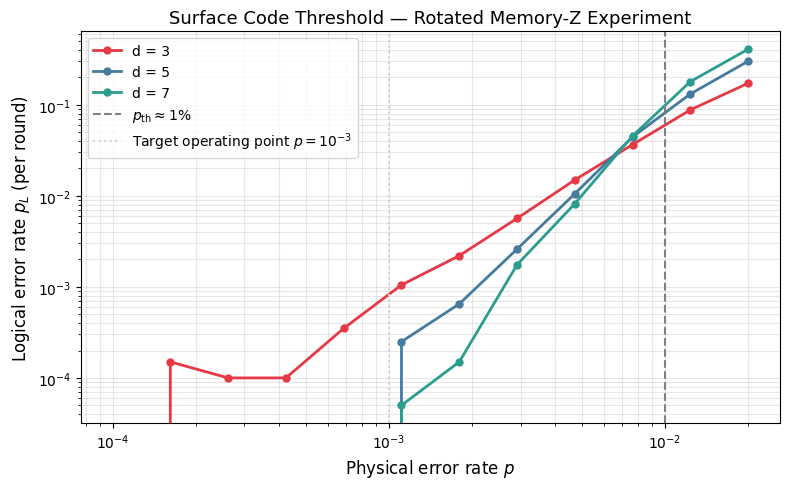

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
colors_d = {3: '#e63946', 5: '#457b9d', 7: '#2a9d8f'}

for d in distances:
    ax.plot(physical_error_rates, results[d], 'o-',
            color=colors_d[d], label=f'd = {d}', linewidth=2, markersize=5)

# Approximate threshold marker
ax.axvline(x=0.01, color='gray', linestyle='--', linewidth=1.5,
           label=r'$p_{\mathrm{th}} \approx 1\%$')
ax.axvline(x=0.001, color='lightgray', linestyle=':', linewidth=1.5,
           label=r'Target operating point $p = 10^{-3}$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Physical error rate $p$', fontsize=12)
ax.set_ylabel('Logical error rate $p_L$ (per round)', fontsize=12)
ax.set_title('Surface Code Threshold — Rotated Memory-Z Experiment', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the threshold plot:**
- **X-axis:** physical error rate $p$ (log scale). The dashed gray line marks the
  approximate threshold $p_{\text{th}} \approx 1\%$.
- **Y-axis:** logical error rate $p_L$ per round (log scale).
- **Below threshold (left of dashed line):** the $d=7$ curve sits well below $d=5$,
  which sits below $d=3$ — increasing $d$ gives exponential improvement.
- **Above threshold (right of dashed line):** the ordering flips. More qubits mean
  more opportunities for errors to accumulate faster than the code can correct.
- **At the dotted line** ($p = 10^{-3}$, a realistic near-term target): the $d=3$
  code already achieves $p_L \ll p$, but you need $d \geq 17$ to reach $p_L \sim 10^{-10}$
  as required by algorithms like Shor's.
- The **slope** of each line in log-log space equals $\lfloor(d+1)/2\rfloor$ —
  for $d=3$ this is 2, for $d=5$ it is 3, for $d=7$ it is 4. You can verify this
  visually from the plot.

### 3.3 Interpreting the Threshold Plot

- **Below threshold ($p < p_{\text{th}}$):** Increasing $d$ exponentially suppresses $p_L$. This is the operating regime for fault-tolerant quantum computing.
- **Above threshold ($p > p_{\text{th}}$):** Increasing $d$ *worsens* $p_L$ — more qubits introduce more noise than the code can correct.
- **At threshold:** All $d$ curves intersect. For the rotated surface code under circuit-level depolarizing noise, $p_{\text{th}} \approx 0.7\%$–$1.1\%$ (varies by noise model and decoder).

**Practical target:** Most fault-tolerant quantum computing proposals assume $p \approx 10^{-3}$, giving a safety factor of ~10× below threshold.

### 3.4 Code Distance Selection

To achieve logical error rate $p_L$ at physical error rate $p$:

$$d \approx 2 \left\lceil \frac{\log(A / p_L)}{2 \log(p_{\text{th}} / p)} \right\rceil + 1$$

For $p = 10^{-3}$, $p_L = 10^{-10}$: this requires $d \approx 17$–$21$ (depending on prefactor $A$).

---
## 4. Decoding with Minimum Weight Perfect Matching (MWPM)

### 4.1 The Decoding Problem

After syndrome extraction:
1. We receive a **syndrome string** — a binary vector indicating which detectors fired.
2. We need to infer a **correction** — a Pauli operator to apply to the data qubits — such that the residual error is in the stabilizer group (no logical effect).

Naively, ML decoding is #P-hard. MWPM gives an efficient approximation optimal in the single-species error case.

### 4.2 Graph Construction for MWPM

For each syndrome type (X or Z separately):

1. **Nodes:** Each detector that fired becomes a node. Add a virtual "boundary" node.
2. **Edges:** Connect pairs of nodes with edge weight $-\log(p_e / (1 - p_e)) \approx -\log(p_e)$, where $p_e$ is the probability of the error path between them.
3. **MWPM:** Find the minimum weight perfect matching on the fired detectors (including boundary node to handle odd-weight syndromes).
4. **Correction:** Apply Paulis along each matched path; determine if a logical flip occurred.

**PyMatching** implements MWPM using a sparse Blossom algorithm (Sparse Blossom, Gidney & Jones 2023) achieving ~$10^6$ corrections/second/core.

### 4.3 Decoding a Single Shot

In [30]:
d = 5
p = 5e-3

circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=d, distance=d,
    after_clifford_depolarization=p,
    before_round_data_depolarization=p,
    after_reset_flip_probability=p,
    before_measure_flip_probability=p,
)

dem = circuit.detector_error_model(decompose_errors=True)
matcher = pymatching.Matching.from_detector_error_model(dem)

sampler = circuit.compile_detector_sampler()
detection_events, observable_flips = sampler.sample(
    shots=1_000, separate_observables=True
)

# Decode all 1000 shots in batch
predictions = matcher.decode_batch(detection_events)

# Count logical errors
num_errors = np.sum(predictions[:, 0] != observable_flips[:, 0])
p_L = num_errors / 1000

print(f"d={d}, p={p}")
print(f"Logical errors in 1000 shots: {num_errors}")
print(f"Estimated logical error rate: {p_L:.4f}")

d=5, p=0.005
Logical errors in 1000 shots: 27
Estimated logical error rate: 0.0270


**Reading the decoding output:**
- `Logical errors in 1000 shots` counts the shots where the decoder's prediction
  disagreed with the actual observable flip — i.e., cases where an error chain
  fooled MWPM into applying the wrong correction.
- At $p = 5 \times 10^{-3}$ with $d = 5$, you should see $p_L$ in the range
  $10^{-2}$–$10^{-3}$: well below the physical error rate, confirming sub-threshold
  operation, but not yet at the deep suppression achievable with larger $d$.
- The `decode_batch()` call processes all 1000 shots simultaneously — PyMatching's
  Sparse Blossom algorithm handles each shot independently and in near-linear time.
- `predictions[:, 0]` is the decoder's guess for observable 0 (the logical Z);
  comparing against `observable_flips[:, 0]` (ground truth from the Stim simulation)
  gives the empirical logical error rate.

### 4.4 Visualizing the Matching Graph

In [31]:
def visualize_syndrome_and_matching(d=3, p=5e-3, seed=42):
    """
    Sample one shot and visualize the syndrome pattern and MWPM matching.
    Displays Z-type detectors only (X error detection).
    """
    np.random.seed(seed)
    circuit = stim.Circuit.generated(
        "surface_code:rotated_memory_x",
        rounds=1, distance=d,
        after_clifford_depolarization=p,
        before_round_data_depolarization=p,
        after_reset_flip_probability=p,
        before_measure_flip_probability=p,
    )
    dem = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)

    sampler = circuit.compile_detector_sampler()

    for shot_idx in range(100):  # try to find a shot with some errors
        detection_events, observable_flips = sampler.sample(
            shots=1, separate_observables=True
        )
        if detection_events.sum() > 0:
            break

    fired_detectors = np.where(detection_events[0])[0]
    print(f"Fired detectors (indices): {fired_detectors}")
    print(f"Number of fired detectors: {len(fired_detectors)}")

    prediction = matcher.decode(detection_events[0])
    logical_flip = prediction[0] != observable_flips[0, 0]
    print(f"Predicted logical flip   : {bool(prediction[0])}")
    print(f"Actual logical flip      : {bool(observable_flips[0, 0])}")
    print(f"Decoding {'FAILED' if logical_flip else 'succeeded'}")

visualize_syndrome_and_matching(d=5, p=8e-3)

Fired detectors (indices): [ 1  2  3  4  6 13]
Number of fired detectors: 6
Predicted logical flip   : False
Actual logical flip      : False
Decoding succeeded


**Reading the matching output:**
- `Fired detectors` lists the indices of detectors that returned value 1 in this shot.
  Each fired detector corresponds to a stabilizer measurement that disagreed with
  expectation — a sign that an error occurred nearby.
- MWPM pairs up these fired detectors into a **perfect matching** — each detector
  is assigned exactly one partner. The correction applies Paulis along each matched
  path through the lattice.
- If `Decoding succeeded`: MWPM identified a correction in the same equivalence class
  as the actual error — the net effect is a stabilizer, not a logical operator.
- If `Decoding FAILED`: MWPM chose a correction in the wrong equivalence class —
  the uncorrected residual error is a logical operator, flipping $\bar{Z}$ or $\bar{X}$.
  This happens when the actual error chain is longer than $d/2$ or when correlated
  errors fool the single-error-path assumption.
- Running the cell multiple times (different `seed` values) will show you both
  success and failure cases.

### 4.5 Alternative Decoders

| Decoder | Method | Notes |
|---|---|---|
| **PyMatching** (MWPM) | Blossom V / Sparse Blossom | Near-linear time, excellent sub-threshold performance |
| **Belief Propagation + OSD** | Iterative BP then ordered statistics | Better on LDPC codes; competitive on surface code |
| **Union Find** | Cluster growth | Near-linear, slightly worse threshold than MWPM |
| **Neural Network** | ML inference | Can incorporate non-Pauli noise; slower training |
| **Chromobius** | Matching on color code | Relevant for color codes, not surface codes |

For surface codes, **PyMatching** (Sparse Blossom) is the practical gold standard at $> 10^6$ corrections/second on a single CPU core (see Gidney & Jones 2023, "Sparse Blossom").

---
## 5. Lattice Surgery & Logical Gates

### 5.1 Overview

Lattice surgery performs logical gates between surface code patches **without physical qubit transport**, making it suitable for 2D nearest-neighbor architectures.

The two fundamental operations are:

| Operation | Description |
|---|---|
| **Merge** | Combine two code patches into one by measuring joint boundary stabilizers |
| **Split** | Separate a merged patch back into two by measuring individual boundary stabilizers |

Measuring the **joint** boundary operators effectively performs a joint measurement $\bar{X}_L \otimes \bar{X}_R$ or $\bar{Z}_L \otimes \bar{Z}_R$, which enables logical gates via teleportation.

### 5.2 Logical CNOT via Lattice Surgery

A fault-tolerant CNOT between two logical qubits L (control) and R (target) is performed in 4 steps:

```
Step 1: Measure  Z_L ⊗ Z_R   (merge on Z boundary)
Step 2: Measure  X_L ⊗ X_R   (merge on X boundary)
Step 3: Apply classically-controlled corrections
Step 4: Split — restore independent patches
```

**Resource cost:** A CNOT between two $d$-distance patches requires an ancilla patch and $O(d)$ time steps.

### 5.3 Logical Clifford Gates Summary

| Gate | Method | Time cost |
|---|---|---|
| $\bar{X}$, $\bar{Z}$ | Apply Pauli correction (classical) | Free |
| $\bar{H}$ | Rotate patch 90° (remap stabilizers) | $O(d)$ rounds |
| $\bar{S}$ | Consume magic state $|Y\rangle$, lattice surgery | $O(d)$ rounds |

### 5.4 Magic State Distillation (T gate)

The $T = \text{diag}(1, e^{i\pi/4})$ gate is outside the Clifford group and cannot be implemented transversally on the surface code.  
Instead:

1. **Prepare** noisy magic states $|T\rangle = T|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + e^{i\pi/4}|1\rangle)$
2. **Distill** many noisy $|T\rangle$ into fewer high-fidelity $|T\rangle$ using the **15-to-1** protocol (or newer variants like the $10^{-15}$ factory from Gidney & Ekerå 2021)
3. **Inject** the distilled $|T\rangle$ via gate teleportation to apply $T$ to a logical qubit

The **magic state factory** dominates the space-time overhead of fault-tolerant algorithms.

### 5.5 Illustrative Lattice Surgery Circuit

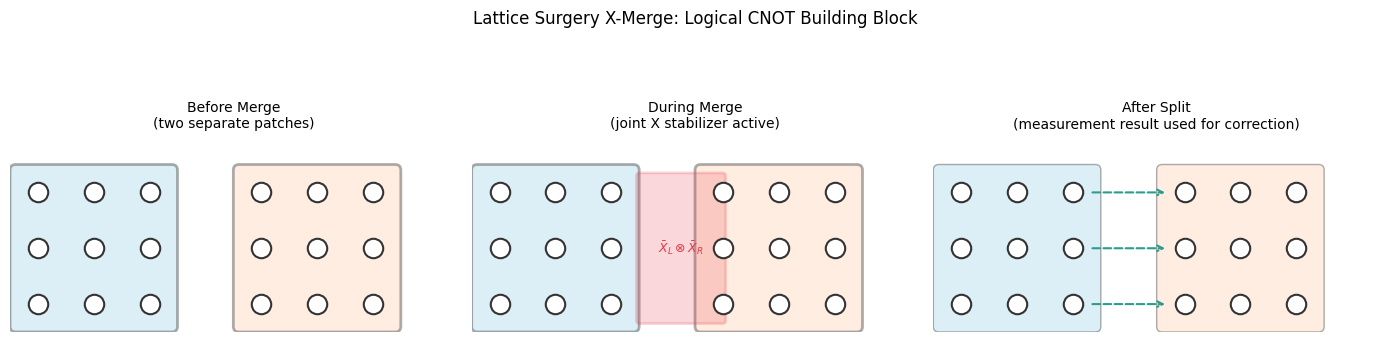

In [32]:
def illustrate_xx_merge():
    """
    Schematic of a 1D lattice surgery X-merge between two d=3 patches.
    Shows boundary data qubits and the joint X stabilizer measured during merge.
    """
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    titles = ['Before Merge\n(two separate patches)',
              'During Merge\n(joint X stabilizer active)',
              'After Split\n(measurement result used for correction)']

    for ax, title in zip(axes, titles):
        ax.set_aspect('equal')
        ax.set_title(title, fontsize=10)
        ax.set_xlim(-0.5, 7.5)
        ax.set_ylim(-0.5, 3)
        ax.axis('off')

    d = 3
    patch_colors = ['#a8d8ea', '#ffd3b6']

    # Draw two patches side by side
    for ax_idx, ax in enumerate(axes):
        for patch_idx, (x_off, color) in enumerate(zip([0, 4], patch_colors)):
            rect = mpatches.FancyBboxPatch(
                (x_off - 0.4, -0.4), d - 0.2, d - 0.2,
                boxstyle="round,pad=0.1",
                linewidth=2 if ax_idx < 2 else 1,
                edgecolor='#333333',
                facecolor=color, alpha=0.4
            )
            ax.add_patch(rect)
            label = [r'$L$', r'$R$'][patch_idx]
            ax.text(x_off + (d - 1) / 2, (d - 1) / 2, label,
                    ha='center', va='center', fontsize=14,
                    fontweight='bold', color='#333333')

            # Data qubits
            for row in range(d):
                for col in range(d):
                    ax.plot(x_off + col, row, 'o', markersize=14,
                            color='white', markeredgecolor='#333333',
                            markeredgewidth=1.5, zorder=3)

        # Merge region
        if ax_idx == 1:
            merge_rect = mpatches.FancyBboxPatch(
                (2.5, -0.3), 1.5, d - 0.4,
                boxstyle="round,pad=0.05",
                linewidth=2, edgecolor='#e63946',
                facecolor='#e63946', alpha=0.2
            )
            ax.add_patch(merge_rect)
            ax.text(3.25, (d - 1) / 2, r'$\bar{X}_L \otimes \bar{X}_R$',
                    ha='center', va='center', fontsize=9,
                    color='#e63946', fontweight='bold')

        if ax_idx == 2:
            for row in range(d):
                ax.annotate('', xy=(4 - 0.3, row), xytext=(2 + 0.3, row),
                            arrowprops=dict(arrowstyle='->', color='#2a9d8f',
                                            lw=1.5, linestyle='dashed'))

    plt.suptitle('Lattice Surgery X-Merge: Logical CNOT Building Block',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

illustrate_xx_merge()

**Reading the merge diagram:**
- **Left panel:** two independent logical qubits L and R encoded in separate $d=3$
  patches. Their boundaries face each other but do not interact.
- **Middle panel:** the merge phase. A new set of **joint boundary stabilizers**
  is turned on (shown in red), effectively measuring $\bar{X}_L \otimes \bar{X}_R$
  across the shared boundary. This projects the two-patch system into a definite
  eigenstate of the joint operator — performing a joint XX measurement.
- **Right panel:** after splitting, the measurement outcome is used as a classical
  correction. The entanglement created during the merge, combined with the
  measurement result, implements a logical operation equivalent to a CNOT step.
- The key insight: no physical qubit moves between patches. All information transfer
  happens through **stabilizer measurement**, making this compatible with fixed 2D
  architectures.
- Each merge/split cycle takes $O(d)$ rounds of syndrome extraction to be
  fault-tolerant — errors during the merge must also be corrected.

### 5.6 Logical CNOT — Stim Circuit

Stim can generate full lattice surgery circuits directly:

In [33]:
# The 'surface_code:rotated_memory_z' task is a memory experiment.
# For multi-patch lattice surgery circuits, Stim's `gen` submodule (sinter)
# or manual circuit construction is used.
#
# Here we demonstrate a manual Z-basis merge (joint ZZ measurement)
# between two logical qubits encoded in d=3 surface code patches.

# For illustration, we show the Stim circuit for a 2-round ZZ merge
# using Stim's low-level circuit API.

# Build a minimal ZZ parity check between qubits 0 and 1 using an ancilla (qubit 2)
zz_meas = stim.Circuit("""
    # Prepare ancilla in |+> state
    R 2
    H 2
    TICK
    # Entangle ancilla with both data qubits (ZZ check)
    CZ 2 0
    CZ 2 1
    TICK
    # Measure ancilla in X basis
    H 2
    M 2
    # Record ZZ parity
    DETECTOR rec[-1]
    OBSERVABLE_INCLUDE(0) rec[-1]
""")

print("Minimal ZZ measurement circuit (schematic):")
print(zz_meas)
print()
print("In a full lattice surgery circuit, this pattern is repeated")
print("across all boundary qubits of the two merging patches,")
print("interleaved with the standard surface code syndrome extraction.")

Minimal ZZ measurement circuit (schematic):
R 2
H 2
TICK
CZ 2 0 2 1
TICK
H 2
M 2
DETECTOR rec[-1]
OBSERVABLE_INCLUDE(0) rec[-1]

In a full lattice surgery circuit, this pattern is repeated
across all boundary qubits of the two merging patches,
interleaved with the standard surface code syndrome extraction.


---
## 6. Tool Reference: Stim, Crumble, and Quirk

### 6.1 Stim

[**Stim**](https://github.com/quantumlib/stim) (Craig Gidney, Google Quantum AI) is a high-performance stabilizer circuit simulator specialized for QEC.

**Key capabilities:**
- Simulates $10^8+$ stabilizer circuit samples per second
- Native support for detectors, observables, and error models
- Generates Detector Error Models (DEMs) for decoder input
- CLI, Python API, and C++ library

#### Stim CLI Examples

In [34]:
# ---- Generate a surface code circuit from the CLI ----
import subprocess, sys

# Python equivalent of:
# stim gen --code surface_code --task rotated_memory_z --distance 3 --rounds 3 --after_clifford_depolarization 0.001

circuit = stim.Circuit.generated(
    code_task="surface_code:rotated_memory_z",
    distance=3, rounds=3,
    after_clifford_depolarization=1e-3,
)

# Save circuit to file (can then be used with stim CLI tools)
with open('/tmp/surface_d3.stim', 'w') as f:
    f.write(str(circuit))
print("Circuit saved to /tmp/surface_d3.stim")

# ---- Explain errors in the DEM ----
dem = circuit.detector_error_model()
print(f"\nDetector Error Model: {dem.num_errors} error mechanisms, {dem.num_detectors} detectors")

# ---- Sample shots using the CLI approach ----
# Equivalent to: stim sample --shots 1000 < circuit.stim
sampler = circuit.compile_sampler()
raw_samples = sampler.sample(shots=5)
print(f"\nRaw measurement samples (5 shots, {raw_samples.shape[1]} bits each):")
print(raw_samples[:5].astype(int))

Circuit saved to /tmp/surface_d3.stim

Detector Error Model: 219 error mechanisms, 24 detectors

Raw measurement samples (5 shots, 33 bits each):
[[0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1 1 1 0 1 1 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1]
 [1 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 1 1 0 1 0 1]
 [0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 0]
 [1 0 1 0 0 1 0 1 1 0 1 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 1]]


**Reading the Stim output:**
- The saved `.stim` file is a plain-text representation of the circuit — you can
  open it in a text editor, paste it into Crumble, or pipe it through the Stim CLI
  (`stim analyze_errors`, `stim sample`, etc.).
- The DEM summary (`N error mechanisms, M detectors`) gives a quick sanity check:
  for a $d=3$, 1-round circuit you expect $O(d^2)$ error mechanisms. Many more
  than expected can indicate a bug in stabilizer ordering or connectivity.
- The raw measurement samples show the full bitstring (all ancilla + data measurements)
  before detector XOR processing. Compare with the detector samples from Section 2
  to see how `DETECTOR` declarations transform raw bits into syndrome bits.

In [37]:
# ---- Explain a specific error mechanism ----
# stim.Circuit.explain_detector_error_model_errors() gives human-readable explanations

circuit_small = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    distance=3, rounds=1,
    after_clifford_depolarization=1e-3,
)

dem_small = circuit_small.detector_error_model(decompose_errors=True)

# Explain error mechanisms in the circuit.
# explain_detector_error_model_errors() takes an optional dem_filter (a DEM)
# to restrict which error mechanisms are explained, but NOT dem= directly.
# Omitting dem_filter explains all error mechanisms in the circuit's own DEM.
explanations = circuit_small.explain_detector_error_model_errors(
    reduce_to_one_representative_error=True,
)
print(f"Total explained error mechanisms: {len(explanations)}")
print("\nFirst 3 error mechanism explanations:")
for i, exp in enumerate(explanations[:3]):
    print(f"\n  [{i}] Dem error: {exp.dem_error_terms}")
    print(f"       Circuit error locations:")
    for loc in exp.circuit_error_locations[:2]:
      print(f"         tick={loc.tick_offset}")
      for pt in loc.flipped_pauli_product:
        print(f"           gate_target={pt.gate_target}  coords={pt.coords}")

Total explained error mechanisms: 23

First 3 error mechanism explanations:

  [0] Dem error: [stim.DemTargetWithCoords(dem_target=stim.DemTarget('D0'), coords=[0, 4, 0])]
       Circuit error locations:
         tick=2
           gate_target=stim.target_x(15)  coords=[1.0, 5.0]
           gate_target=stim.target_x(14)  coords=[0.0, 4.0]

  [1] Dem error: [stim.DemTargetWithCoords(dem_target=stim.DemTarget('D0'), coords=[0, 4, 0]), stim.DemTargetWithCoords(dem_target=stim.DemTarget('D1'), coords=[2, 2, 0])]
       Circuit error locations:
         tick=3
           gate_target=stim.target_x(8)  coords=[1.0, 3.0]
           gate_target=stim.target_x(14)  coords=[0.0, 4.0]

  [2] Dem error: [stim.DemTargetWithCoords(dem_target=stim.DemTarget('D0'), coords=[0, 4, 0]), stim.DemTargetWithCoords(dem_target=stim.DemTarget('D4'), coords=[0, 4, 1])]
       Circuit error locations:
         tick=2
           gate_target=stim.target_x(14)  coords=[0.0, 4.0]


**Reading the error explanations:**
- Each explanation links one **DEM error mechanism** (an abstract edge in the matching
  graph) back to a **concrete physical fault** in the circuit — a specific gate, at a
  specific time step, on specific qubits.
- `tick_offset` tells you which `TICK`-separated layer the fault occurs in. Layer 0
  is before the first `TICK`, layer 1 is between `TICK` 1 and 2, and so on.
- `flipped_pauli_product` lists the Pauli operators that the fault injects. For example,
  a `DEPOLARIZE2` event on a CNOT might inject `X` on the control and `Z` on the target.
- `gate_target` and `coords` identify the qubit — coords map back to the 2D layout
  you can visualize in Crumble.
- This API is invaluable for **debugging custom circuits**: if a DEM edge has
  unexpectedly high probability, trace it back here to find the offending gate.

### 6.2 Crumble — Interactive 2D QEC Circuit Builder

[**Crumble**](https://algassert.com/crumble) (Craig Gidney, 2023) is a browser-based point-and-click tool for building and inspecting QEC circuits, especially surface codes.

**Key features:**
- Visual 2D qubit layout editor
- Click to place gates, add errors, define detectors
- Import/export Stim circuits directly
- Visualize stabilizer flows and detector regions
- Useful for understanding and debugging custom QEC circuits

**Typical workflow with Crumble:**

```
1. Open https://algassert.com/crumble in your browser
2. Build your circuit visually (or paste a Stim circuit string)
3. Inspect detector regions — color-coded overlays show which
   measurements contribute to each detector
4. Export the .stim circuit for use in Stim/PyMatching
```

**Loading a Stim circuit into Crumble programmatically:**

In [38]:
import urllib.parse

def open_in_crumble(circuit: stim.Circuit, print_url: bool = True) -> str:
    """
    Generate a Crumble URL for a given Stim circuit.
    Open in a browser to inspect the circuit visually.
    """
    circuit_str = str(circuit)
    encoded = urllib.parse.quote(circuit_str, safe='')
    url = f"https://algassert.com/crumble#circuit={encoded}"
    if print_url:
        print("Open this URL in your browser to view the circuit in Crumble:")
        print()
        # Print first 200 chars of URL
        print(url[:300] + '...' if len(url) > 300 else url)
    return url

# Generate a small d=3 circuit and create its Crumble URL
small_circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    distance=3, rounds=2,
    after_clifford_depolarization=1e-3,
)

crumble_url = open_in_crumble(small_circuit)

# In a Jupyter notebook, you can display this as a clickable link:
from IPython.display import HTML, display
display(HTML(f'<a href="{crumble_url}" target="_blank">🔗 Open d=3 Surface Code in Crumble</a>'))

Open this URL in your browser to view the circuit in Crumble:

https://algassert.com/crumble#circuit=QUBIT_COORDS%281%2C%201%29%201%0AQUBIT_COORDS%282%2C%200%29%202%0AQUBIT_COORDS%283%2C%201%29%203%0AQUBIT_COORDS%285%2C%201%29%205%0AQUBIT_COORDS%281%2C%203%29%208%0AQUBIT_COORDS%282%2C%202%29%209%0AQUBIT_COORDS%283%2C%203%29%2010%0AQUBIT_COORDS%284%2C%202%29%201...


**What to look for in Crumble:**
- Each qubit appears as a circle at its `QUBIT_COORDS` position. Data qubits (odd
  coordinates in the rotated code) and ancilla qubits (even coordinates) are
  distinguishable by which gates act on them.
- Click any **detector** to highlight its **detector region** — the set of measurements
  that XOR together to form it. For a Z-type ancilla, you should see it touching
  exactly 4 data qubits (or 2 at boundaries).
- The **time axis** scrolls left-to-right through `TICK` layers. You can step through
  one gate layer at a time to verify the CX ordering follows the canonical pattern
  (NE → NW → SE → SW for Z-type ancillas, reversed for X-type).
- If any detector region looks unexpected (wrong number of qubits, crosses round
  boundaries incorrectly), it indicates a circuit bug — often a wrong CX direction
  or a missing H gate.

### 6.3 Quirk — Quantum Circuit Simulator

[**Quirk**](https://algassert.com/quirk) (Craig Gidney, 2016) is a browser-based drag-and-drop quantum circuit simulator with real-time state visualization.

**Key features:**
- Real-time amplitude/Bloch sphere display per qubit
- Supports up to ~16 qubits (full statevector)
- Useful for visualizing small QEC gadgets: Bell state prep, teleportation, stabilizer measurements
- Share circuits via URL

**Note:** Quirk simulates exact statevectors, so it's complementary to Stim (which uses the stabilizer tableau representation and handles much larger circuits/noisy simulations).

**Example use cases for Quirk in surface code education:**
- Visualize how a single Z ancilla measures a Z stabilizer on 4 data qubits
- Demonstrate bit-flip code encoding and syndrome measurement
- Show gate teleportation for T gates

In [39]:
# Generate a Quirk URL for a small stabilizer measurement gadget
# This encodes a Z-stabilizer measurement on 4 data qubits using an ancilla

import json

# Quirk circuit: ancilla (qubit 0) measures ZZZZ on qubits 1-4
quirk_circuit = {
    "cols": [
        # Reset ancilla
        ["~reset", 1, 1, 1, 1],
        # H on ancilla to prepare |+>
        ["H"],
        # CNOT from each data qubit to ancilla (ZZ coupling)
        ["•", "Z"],
        ["•", 1, "Z"],
        ["•", 1, 1, "Z"],
        ["•", 1, 1, 1, "Z"],
        # H on ancilla then measure
        ["H"],
        ["Measure"]
    ]
}

quirk_url = "https://algassert.com/quirk#circuit=" + urllib.parse.quote(
    json.dumps(quirk_circuit), safe=''
)
print("Quirk circuit: Z-stabilizer measurement gadget")
display(HTML(f'<a href="{quirk_url}" target="_blank">🔗 Open Z-stabilizer gadget in Quirk</a>'))

Quirk circuit: Z-stabilizer measurement gadget


**What to look for in Quirk:**
- The top row shows the **ancilla qubit** state in real time as you step through gates.
  After the initial H it is in $|+\rangle = (|0\rangle + |1\rangle)/\sqrt{2}$.
- After each `CZ` with a data qubit, watch how the ancilla's phase tracks the
  parity of the data qubit's Z eigenvalue. If the data qubit is in $|1\rangle$,
  the ancilla picks up a phase flip.
- After the final H and measurement, the ancilla outcome (0 or 1) gives the **Z
  parity of all 4 data qubits** — this is exactly the Z-stabilizer syndrome bit.
- Try setting one data qubit to $|1\rangle$ (click it to toggle) and re-run: the
  ancilla measurement outcome flips, showing that the stabilizer correctly detects
  the single-qubit Z error.
- **Quirk vs Stim:** Quirk shows you the exact quantum state at each step (useful
  for gadget intuition), while Stim simulates millions of noisy shots in seconds
  (useful for threshold estimation). Use both together.

---
## 7. Summary & Further Reading

### Core Concepts Recap

| Concept | Key formula / fact |
|---|---|
| Rotated surface code qubits | $2d^2 - 1$ total, encodes 1 logical qubit |
| Code distance | Minimum weight of $\bar{X}$ or $\bar{Z}$ logical operator |
| Error correction capacity | Corrects up to $\lfloor (d-1)/2 \rfloor$ arbitrary errors |
| Threshold (circuit noise) | $p_{\text{th}} \approx 0.7\%$–$1.1\%$ |
| Logical error rate | $p_L \sim (p/p_{\text{th}})^{\lfloor (d+1)/2 \rfloor}$ |
| Decoder | MWPM via PyMatching (Sparse Blossom) |
| Logical gates | Clifford: lattice surgery; T: magic state distillation |

### Recommended Papers

1. **Fowler et al. (2012)** — "Surface codes: Towards practical large-scale quantum computation" — *PRA 86, 032324*. The definitive surface code review.
2. **Gidney & Ekerå (2021)** — "How to factor 2048 bit RSA integers in 8 hours using 20 million noisy qubits" — *Quantum 5, 433*. Resource estimation with surface codes.
3. **Gidney (2021)** — "Stim: a fast stabilizer circuit simulator" — *Quantum 5, 497*.
4. **Higgott & Gidney (2023)** — "Sparse Blossom: correcting a million errors per core second with minimum-weight matching" — *arXiv:2303.15933*.
5. **Gidney et al. (2023)** — "Yoked surface codes" — *arXiv:2312.04522*. Halves logical qubit overhead.
6. **Google Quantum AI (2023)** — "Suppressing quantum errors by scaling a surface code logical qubit" — *Nature 614, 676*.

### Key Tools

| Tool | URL | Purpose |
|---|---|---|
| Stim | https://github.com/quantumlib/stim | Fast QEC circuit simulation |
| PyMatching | https://github.com/oscartyrrell/PyMatching | MWPM decoder |
| Crumble | https://algassert.com/crumble | Visual circuit builder |
| Quirk | https://algassert.com/quirk | Small circuit visualizer |
| Sinter | (part of Stim repo) | Threshold sampling & plotting |

---
*Tutorial based on Craig Gidney's Algorithmic Assertions (https://algassert.com/) and associated papers.*